In [1]:
import os
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics --upgrade -q
import os, random, shutil, cv2
from ultralytics import YOLO

# Base directories
base_dir = "/content/drive/MyDrive/Datasets"
kitti_dir = f"{base_dir}/kitti_dataset"
mini_dir = f"{base_dir}/mini_dataset"

# Clean previous datasets
if os.path.exists(mini_dir):
    shutil.rmtree(mini_dir)
os.makedirs(f"{mini_dir}/images/train", exist_ok=True)
os.makedirs(f"{mini_dir}/images/val", exist_ok=True)
os.makedirs(f"{mini_dir}/labels/train", exist_ok=True)
os.makedirs(f"{mini_dir}/labels/val", exist_ok=True)

# ===============================
# 2. Download KITTI (only once)
# ===============================
if not os.path.exists(kitti_dir):
    os.makedirs(kitti_dir, exist_ok=True)
    !wget -nc -P {kitti_dir} https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip
    !wget -nc -P {kitti_dir} https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip
    !unzip -q {kitti_dir}/data_object_image_2.zip -d {kitti_dir}
    !unzip -q {kitti_dir}/data_object_label_2.zip -d {kitti_dir}
    print(" KITTI downloaded & extracted")

# Directories inside KITTI
img_dir = f"{kitti_dir}/training/image_2"
label_dir = f"{kitti_dir}/training/label_2"

# ===============================
# 3. Conversion Function (KITTI → YOLO)
# ===============================
CLASS_MAP = {"Car": 0, "Pedestrian": 1, "Cyclist": 2, "Truck": 3}

def convert_kitti_to_yolo(kitti_label_path, img_w, img_h):
    lines_out = []
    with open(kitti_label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 8:
                continue
            cls = parts[0]
            if cls not in CLASS_MAP:
                continue

            left, top, right, bottom = map(float, parts[4:8])
            w = right - left
            h = bottom - top
            if w <= 1 or h <= 1:
                continue

            x_center = (left + right) / 2.0 / img_w
            y_center = (top + bottom) / 2.0 / img_h
            w_n = w / img_w
            h_n = h / img_h

            cls_id = CLASS_MAP[cls]
            lines_out.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {w_n:.6f} {h_n:.6f}")
    return lines_out

# ===============================
# 4. Build Mini Dataset (2000 imgs)
# ===============================
all_images = [f for f in os.listdir(img_dir) if f.endswith(".png")]
random.shuffle(all_images)

train_imgs = all_images[:1800]
val_imgs = all_images[1800:2000]

def process_split(img_list, split):
    for img in img_list:
        base = img.replace(".png", "")
        src_img = os.path.join(img_dir, img)
        src_lbl = os.path.join(label_dir, base + ".txt")

        # Copy image
        dst_img = f"{mini_dir}/images/{split}/{img}"
        shutil.copy(src_img, dst_img)

        # Convert label
        if os.path.exists(src_lbl):
            image = cv2.imread(src_img)
            h, w = image.shape[:2]
            yolo_labels = convert_kitti_to_yolo(src_lbl, w, h)
            if yolo_labels:
                with open(f"{mini_dir}/labels/{split}/{base}.txt", "w") as f:
                    f.write("\n".join(yolo_labels))

process_split(train_imgs, "train")
process_split(val_imgs, "val")

print(f" Mini dataset created with {len(train_imgs)} train and {len(val_imgs)} val images")

# ===============================
# 5. Create data.yaml
# ===============================
data_yaml = f"{mini_dir}/data.yaml"
with open(data_yaml, "w") as f:
    f.write(f"""
train: {mini_dir}/images/train
val: {mini_dir}/images/val

nc: 4
names: ['Car', 'Pedestrian', 'Cyclist', 'Truck']
""")
print(" data.yaml created at:", data_yaml)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--2025-10-24 08:11:18--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.138.228, 52.219.72.143, 3.5.135.82, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.138.228|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12569945557 (12G) [application/zip]
Saving to: ‘/content/drive/MyDrive/Datasets/kitti_dataset/data_object_image_2.zip’

data_object_image_2 100%[===================>]  11.71G  20.3MB/s    in 9m 17s  

2025-10-24 08:20:36 (21.5 MB/s) -

In [3]:
# ===============================
# 6. Train YOLOv8n
# ===============================
runs_dir = f"{base_dir}/runs/kitti_mini"
os.makedirs(runs_dir, exist_ok=True)

model = YOLO("yolov8n.pt")  # pretrained weights
model.train(
    data=data_yaml,
    epochs=180,         # you can increase to 180 for better accuracy
    imgsz=640,
    batch=16,
    name="kitti_mini_ft",
    project=runs_dir,
    cache="disk"
)

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Datasets/mini_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=180, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=kitti_mini_ft, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c5c1b498bf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [4]:
metrics = model.val(
    data="/content/drive/MyDrive/Datasets/mini_dataset/data.yaml",
    imgsz=640
)
print(metrics)

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 345.6±96.3 MB/s, size: 834.2 KB)
val: Scanning /content/drive/MyDrive/Datasets/mini_dataset/labels/val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 235.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 6.6it/s 2.0s
                   all        200        932      0.916      0.737      0.827      0.591
                   Car        177        759      0.935      0.858       0.93      0.739
            Pedestrian         45        105      0.859       0.64      0.781      0.412
               Cyclist         26         35      0.874      0.571      0.678      0.449
                 Truck         30         33      0.996      0.879      0.918      0.764
Speed: 0.7

In [5]:
from ultralytics import YOLO

# Load trained model
model_path = f"{runs_dir}/kitti_mini_ft/weights/best.pt"
model = YOLO(model_path)

# Evaluate on validation set
results = model.val(data=data_yaml, imgsz=640, batch=16)

# Extract overall metrics
precision = results.box.mp   # mean precision across classes
recall = results.box.mr      # mean recall across classes
map50 = results.box.map50    # mean AP @0.5
map50_95 = results.box.map    # mean AP @0.5:0.95

accuracy_percent = map50 * 100

print(f" YOLOv8 Mini-KITTI Evaluation Metrics:")
print(f"Mean Precision: {precision:.4f}")
print(f"Mean Recall: {recall:.4f}")
print(f"mAP50: {map50:.4f}")
print(f"mAP50-95: {map50_95:.4f}")
print(f"Approximate Accuracy (mAP50) in %: {accuracy_percent:.2f}%")

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 386.6±34.4 MB/s, size: 778.4 KB)
val: Scanning /content/drive/MyDrive/Datasets/mini_dataset/labels/val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 367.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 6.7it/s 1.9s
                   all        200        932      0.916      0.737      0.827      0.591
                   Car        177        759      0.935      0.858       0.93      0.739
            Pedestrian         45        105      0.859       0.64      0.781      0.412
               Cyclist         26         35      0.874      0.571      0.678      0.449
                 Truck         30         33      0.996      0.879      0.918      0.764
Speed: 0.6

In [6]:
import os

# Path to your YOLO mini dataset
label_dir = "/content/drive/MyDrive/Datasets/mini_dataset/labels/train"

# Check a few label files
sample_labels = os.listdir(label_dir)[:5]
print(" Checking sample YOLO label files...\n")

for lbl in sample_labels:
    print(f" {lbl}:")
    with open(os.path.join(label_dir, lbl), "r") as f:
        print(f.read().strip(), "\n")


 Checking sample YOLO label files...

 003644.txt:
1 0.955161 0.643840 0.088068 0.542827
1 0.344875 0.534693 0.011860 0.121813 

 005540.txt:
2 0.417071 0.696054 0.133260 0.441514
1 0.072712 0.602446 0.026961 0.297919
1 0.148125 0.585770 0.032410 0.254568 

 002779.txt:
0 0.193124 0.580707 0.067150 0.153787
0 0.223398 0.573880 0.049533 0.100933
0 0.606808 0.516013 0.038043 0.074907 

 005858.txt:
0 0.496828 0.524387 0.034622 0.108453
0 0.040966 0.630813 0.081932 0.266213
0 0.848205 0.703267 0.229163 0.530427
0 0.748422 0.620627 0.184074 0.321360
0 0.663861 0.581027 0.141747 0.221893
0 0.624183 0.551813 0.113422 0.194613
0 0.610870 0.539360 0.103462 0.147840
0 0.593088 0.525133 0.090507 0.135760
0 0.578502 0.511507 0.072126 0.090640
0 0.426634 0.504040 0.019791 0.048027
0 0.541369 0.493480 0.045491 0.056667
0 0.401506 0.493680 0.020531 0.047787 

 002000.txt:
0 0.124175 0.770851 0.248350 0.452892
2 0.825723 0.492824 0.031005 0.189162
0 0.850343 0.488365 0.137042 0.131703
0 0.373971 0.50

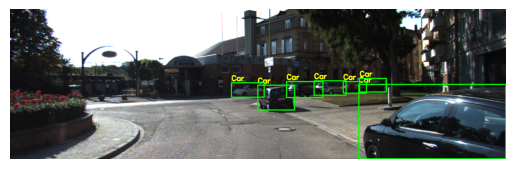

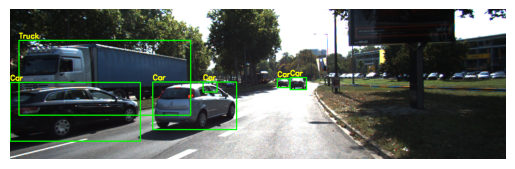

In [7]:
import cv2
import matplotlib.pyplot as plt

# Paths
img_dir = "/content/drive/MyDrive/Datasets/mini_dataset/images/train"
label_dir = "/content/drive/MyDrive/Datasets/mini_dataset/labels/train"

# Class names (same as CLASS_MAP)
CLASS_NAMES = ["Car", "Pedestrian", "Cyclist", "Truck"]

# Function to visualize YOLO labels
def visualize_yolo_image(image_path, label_path, class_names):
    img = cv2.imread(image_path)
    if img is None:
        print(" Image not found:", image_path)
        return
    h, w = img.shape[:2]
    with open(label_path, "r") as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            cls = int(cls)
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, class_names[cls], (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Show 3 random samples
import random
samples = random.sample(os.listdir(img_dir), 3)

for s in samples:
    img_path = os.path.join(img_dir, s)
    lbl_path = os.path.join(label_dir, s.replace(".png", ".txt"))
    if os.path.exists(lbl_path):
        visualize_yolo_image(img_path, lbl_path, CLASS_NAMES)


In [8]:
!pip install ultralytics -q
import os
from ultralytics import YOLO

In [9]:
# Create base directory
base_dir = "/content/drive/MyDrive/Datasets"
os.makedirs(base_dir, exist_ok=True)

# Download KITTI Road Dataset
!wget -nc https://s3.eu-central-1.amazonaws.com/avg-kitti/data_road.zip -O {base_dir}/data_road.zip

# Extract dataset
!unzip -q {base_dir}/data_road.zip -d {base_dir}/kitti_road
print(" KITTI Road dataset ready at:", base_dir + "/kitti_road")

--2025-10-24 09:05:20--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_road.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 52.219.46.39, 3.5.139.0, 3.5.134.70, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|52.219.46.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 470992343 (449M) [application/zip]
Saving to: ‘/content/drive/MyDrive/Datasets/data_road.zip’

/content/drive/MyDr 100%[===================>] 449.17M  22.0MB/s    in 21s     

2025-10-24 09:05:42 (21.3 MB/s) - ‘/content/drive/MyDrive/Datasets/data_road.zip’ saved [470992343/470992343]

 KITTI Road dataset ready at: /content/drive/MyDrive/Datasets/kitti_road


In [10]:
import os
import shutil

base_yolo = f"{base_dir}/kitti_road/yolo_road"
os.makedirs(f"{base_yolo}/images/train", exist_ok=True)
os.makedirs(f"{base_yolo}/images/val", exist_ok=True)
os.makedirs(f"{base_yolo}/labels/train", exist_ok=True)
os.makedirs(f"{base_yolo}/labels/val", exist_ok=True)

print(" YOLO folders created successfully!")


 YOLO folders created successfully!


In [11]:
import cv2
import numpy as np
from tqdm import tqdm

IMG_DIR = f"{base_dir}/kitti_road/data_road/training/image_2"
MASK_DIR = f"{base_dir}/kitti_road/data_road/training/gt_image_2"
YOLO_IMG_DIR = f"{base_yolo}/images/train"
YOLO_LABEL_DIR = f"{base_yolo}/labels/train"

for file in tqdm(os.listdir(IMG_DIR)):
    if not file.endswith(".png"):
        continue

    img_path = os.path.join(IMG_DIR, file)
    mask_path = os.path.join(MASK_DIR, file.replace(".png", "_road_000.png"))

    if not os.path.exists(mask_path):
        continue

    # Copy image
    shutil.copy(img_path, os.path.join(YOLO_IMG_DIR, file))

    # Read mask and generate bounding box
    mask = cv2.imread(mask_path, 0)
    if mask is None:
        continue

    # Threshold and find contours
    _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = mask.shape
    label_path = os.path.join(YOLO_LABEL_DIR, file.replace(".png", ".txt"))

    with open(label_path, "w") as f:
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            x_c = (x + bw / 2) / w
            y_c = (y + bh / 2) / h
            bw /= w
            bh /= h
            f.write(f"0 {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}\n")


100%|██████████| 289/289 [00:00<00:00, 6959.56it/s]


In [12]:
# ==========================================
# 1️ Install YOLO and Import Dependencies
# ==========================================
!pip install ultralytics -q
import os
import shutil
import cv2
import numpy as np
from tqdm import tqdm
from glob import glob

base_dir = "/content/drive/MyDrive/Datasets"
kitti_dir = f"{base_dir}/kitti_road"
yolo_dir = f"{kitti_dir}/yolo_road"

os.makedirs(yolo_dir, exist_ok=True)
print(" Environment ready.")

 Environment ready.


In [13]:
# ==========================================
# 2️y Download + Extract KITTI Road Dataset
# ==========================================
!wget -nc https://s3.eu-central-1.amazonaws.com/avg-kitti/data_road.zip -O {base_dir}/data_road.zip
!unzip -q {base_dir}/data_road.zip -d {kitti_dir}
print(" KITTI Road dataset extracted to:", kitti_dir)


File ‘/content/drive/MyDrive/Datasets/data_road.zip’ already there; not retrieving.
replace /content/drive/MyDrive/Datasets/kitti_road/data_road/training/image_2/umm_000032.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/Datasets/kitti_road/data_road/training/image_2/umm_000031.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/Datasets/kitti_road/data_road/training/image_2/umm_000030.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/Datasets/kitti_road/data_road/training/image_2/umm_000029.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/Datasets/kitti_road/data_road/training/image_2/umm_000028.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/Datasets/kitti_road/data_road/training/image_2/umm_000027.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/Datasets/kitti_road/data_road/training/image_2/umm_000026.png? [y]es, [n]o, [A]ll

In [14]:
import os
import shutil

base_yolo = f"{base_dir}/kitti_road/yolo_road"
os.makedirs(f"{base_yolo}/images/train", exist_ok=True)
os.makedirs(f"{base_yolo}/images/val", exist_ok=True)
os.makedirs(f"{base_yolo}/labels/train", exist_ok=True)
os.makedirs(f"{base_yolo}/labels/val", exist_ok=True)

print(" YOLO folders created successfully!")


 YOLO folders created successfully!


In [15]:
# ==========================================
# 4️ Convert KITTI Masks → YOLO Labels
# ==========================================
IMG_DIR = f"{kitti_dir}/data_road/training/image_2"
MASK_DIR = f"{kitti_dir}/data_road/training/gt_image_2"

YOLO_IMG_DIR = f"{yolo_dir}/images/train"
YOLO_LABEL_DIR = f"{yolo_dir}/labels/train"

valid_labels = 0
missing_masks = 0

for file in tqdm(os.listdir(IMG_DIR)):
    if not file.endswith(".png"):
        continue

    img_path = os.path.join(IMG_DIR, file)

    # Possible mask name patterns (KITTI has lane_ or road_)
    possible_masks = [
        file.replace(".png", "_road_000.png"),
        file.replace(".png", "_lane_000.png")
    ]

    mask_path = None
    for pm in possible_masks:
        full_path = os.path.join(MASK_DIR, pm)
        if os.path.exists(full_path):
            mask_path = full_path
            break

    if mask_path is None:
        missing_masks += 1
        continue

    # Copy image to YOLO image folder
    shutil.copy(img_path, os.path.join(YOLO_IMG_DIR, file))

    # Read and threshold mask
    mask = cv2.imread(mask_path, 0)
    _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = mask.shape
    label_path = os.path.join(YOLO_LABEL_DIR, file.replace(".png", ".txt"))

    with open(label_path, "w") as f:
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            x_c = (x + bw / 2) / w
            y_c = (y + bh / 2) / h
            bw /= w
            bh /= h
            f.write(f"0 {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}\n")

    valid_labels += 1

print(f" Label generation complete.")
print(f"Train images with labels: {valid_labels}")
print(f"Missing masks (no labels): {missing_masks}")


100%|██████████| 289/289 [00:00<00:00, 3551.07it/s]

 Label generation complete.
Train images with labels: 0
Missing masks (no labels): 289


In [16]:
import os, shutil, zipfile, cv2
from tqdm import tqdm

# ==========================================
# 1️ Download KITTI Road Dataset
# ==========================================
!wget -q https://s3.eu-central-1.amazonaws.com/avg-kitti/data_road.zip -O data_road.zip
!unzip -q data_road.zip -d /content/drive/MyDrive/Datasets/kitti_road/

base_dir = "/content/drive/MyDrive/Datasets/kitti_road/data_road"
img_dir = f"{base_dir}/training/image_2"
mask_dir = f"{base_dir}/training/gt_image_2"

# ==========================================
# 2️ Create YOLO Dataset Structure
# ==========================================
yolo_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane"
for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(f"{yolo_dir}/{sub}", exist_ok=True)

# ==========================================
# 3️ Generate YOLO Labels (correct lane-mapping)
# ==========================================
IMG_TRAIN_DIR = f"{yolo_dir}/images/train"
LABEL_TRAIN_DIR = f"{yolo_dir}/labels/train"

valid_labels = 0
missing_masks = 0

for img_file in tqdm(sorted(os.listdir(img_dir))):
    if not img_file.endswith(".png"):
        continue

    # Example: um_000000.png → um_lane_000000.png
    prefix = img_file.split("_")[0]  # e.g. 'um'
    suffix = "_".join(img_file.split("_")[1:])  # e.g. '000000.png'
    mask_file = f"{prefix}_lane_{suffix}"

    img_path = os.path.join(img_dir, img_file)
    mask_path = os.path.join(mask_dir, mask_file)

    if not os.path.exists(mask_path):
        missing_masks += 1
        continue

    # Copy image
    shutil.copy(img_path, os.path.join(IMG_TRAIN_DIR, img_file))

    # Read mask and find contours
    mask = cv2.imread(mask_path, 0)
    _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = mask.shape
    label_path = os.path.join(LABEL_TRAIN_DIR, img_file.replace(".png", ".txt"))

    with open(label_path, "w") as f:
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            x_c = (x + bw / 2) / w
            y_c = (y + bh / 2) / h
            bw /= w
            bh /= h
            f.write(f"0 {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}\n")

    valid_labels += 1

print(f" Label generation complete.")
print(f"Train images with labels: {valid_labels}")
print(f"Missing masks (no labels): {missing_masks}")

# ==========================================
# 4️ Split Train/Val (90/10 split)
# ==========================================
from sklearn.model_selection import train_test_split

images = sorted(os.listdir(IMG_TRAIN_DIR))
train_imgs, val_imgs = train_test_split(images, test_size=0.1, random_state=42)

for img in val_imgs:
    label = img.replace(".png", ".txt")
    shutil.move(os.path.join(IMG_TRAIN_DIR, img), f"{yolo_dir}/images/val/{img}")
    shutil.move(os.path.join(LABEL_TRAIN_DIR, label), f"{yolo_dir}/labels/val/{label}")

print(" Split complete.")
print("Train images:", len(os.listdir(f'{yolo_dir}/images/train')))
print("Train labels:", len(os.listdir(f'{yolo_dir}/labels/train')))
print("Val images:", len(os.listdir(f'{yolo_dir}/images/val')))
print("Val labels:", len(os.listdir(f'{yolo_dir}/labels/val')))


y
y
y
y
^C
[data_road.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of data_road.zip or
        data_road.zip.zip, and cannot find data_road.zip.ZIP, period.


100%|██████████| 289/289 [00:02<00:00, 112.68it/s]


 Label generation complete.
Train images with labels: 95
Missing masks (no labels): 194
 Split complete.
Train images: 85
Train labels: 85
Val images: 10
Val labels: 10


In [17]:
import os

# ---------------- PATHS ----------------
IMG_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/train"
LABEL_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels/train"
IMG_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/val"
LABEL_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels/val"

def check_pairs(img_dir, label_dir):
    images = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
    labels = sorted([f for f in os.listdir(label_dir) if f.endswith(".txt")])

    missing_labels = [img for img in images if img.replace(".png", ".txt") not in labels]
    missing_images = [lbl for lbl in labels if lbl.replace(".txt", ".png") not in images]

    print(f"\n Checking: {os.path.basename(img_dir).upper()}")
    print(f"Total Images: {len(images)} | Total Labels: {len(labels)}")
    print(f" Valid Pairs: {len(images) - len(missing_labels)}")
    print(f" Missing Labels: {len(missing_labels)} |  Missing Images: {len(missing_images)}")

    if missing_labels:
        print("\nSome images without labels:", missing_labels[:5])
    if missing_images:
        print("\nSome labels without images:", missing_images[:5])

# ---------------- RUN CHECK ----------------
check_pairs(IMG_TRAIN_DIR, LABEL_TRAIN_DIR)
check_pairs(IMG_VAL_DIR, LABEL_VAL_DIR)


 Checking: TRAIN
Total Images: 85 | Total Labels: 85
 Valid Pairs: 85
 Missing Labels: 0 |  Missing Images: 0

 Checking: VAL
Total Images: 10 | Total Labels: 10
 Valid Pairs: 10
 Missing Labels: 0 |  Missing Images: 0


In [18]:
import os
import random
import shutil
from tqdm import tqdm

# -------------------- PATHS --------------------
IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images"
LABEL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels"

IMG_TRAIN_DIR = os.path.join(IMG_DIR, "train")
IMG_VAL_DIR = os.path.join(IMG_DIR, "val")
LABEL_TRAIN_DIR = os.path.join(LABEL_DIR, "train")
LABEL_VAL_DIR = os.path.join(LABEL_DIR, "val")

# Create dirs if missing
os.makedirs(IMG_TRAIN_DIR, exist_ok=True)
os.makedirs(IMG_VAL_DIR, exist_ok=True)
os.makedirs(LABEL_TRAIN_DIR, exist_ok=True)
os.makedirs(LABEL_VAL_DIR, exist_ok=True)

# -------------------- SPLIT RATIO --------------------
train_ratio = 0.9  # 90% train, 10% validation

# Get all available image-label pairs
all_images = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".png")])
valid_pairs = [f for f in all_images if os.path.exists(os.path.join(LABEL_DIR, f.replace(".png", ".txt")))]

print(f"Total images found: {len(all_images)}")
print(f"Images with valid labels: {len(valid_pairs)}")

# -------------------- SHUFFLE AND SPLIT --------------------
random.shuffle(valid_pairs)
split_index = int(len(valid_pairs) * train_ratio)

train_files = valid_pairs[:split_index]
val_files = valid_pairs[split_index:]

print(f"\nSplitting into:")
print(f"Train: {len(train_files)} | Val: {len(val_files)}")

# -------------------- MOVE FILES --------------------
def move_files(file_list, img_dest, label_dest):
    for f in tqdm(file_list, desc=f"Moving to {img_dest.split('/')[-1]}"):
        img_src = os.path.join(IMG_DIR, f)
        label_src = os.path.join(LABEL_DIR, f.replace(".png", ".txt"))
        if os.path.exists(img_src) and os.path.exists(label_src):
            shutil.copy(img_src, os.path.join(img_dest, f))
            shutil.copy(label_src, os.path.join(label_dest, f.replace(".png", ".txt")))

move_files(train_files, IMG_TRAIN_DIR, LABEL_TRAIN_DIR)
move_files(val_files, IMG_VAL_DIR, LABEL_VAL_DIR)

print("\n Split complete.")
print(f"Train images: {len(os.listdir(IMG_TRAIN_DIR))}")
print(f"Train labels: {len(os.listdir(LABEL_TRAIN_DIR))}")
print(f"Val images: {len(os.listdir(IMG_VAL_DIR))}")
print(f"Val labels: {len(os.listdir(LABEL_VAL_DIR))}")

Total images found: 0
Images with valid labels: 0

Splitting into:
Train: 0 | Val: 0


Moving to train: 0it [00:00, ?it/s]
Moving to val: 0it [00:00, ?it/s]


 Split complete.
Train images: 85
Train labels: 85
Val images: 10
Val labels: 10


In [19]:
def verify_pairs(img_dir, label_dir, split_name):
    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
    label_files = sorted([f for f in os.listdir(label_dir) if f.endswith(".txt")])

    valid_pairs = 0
    missing_labels = []
    missing_images = []

    for img in img_files:
        lbl = img.replace(".png", ".txt")
        if lbl in label_files:
            valid_pairs += 1
        else:
            missing_labels.append(img)

    for lbl in label_files:
        img = lbl.replace(".txt", ".png")
        if img not in img_files:
            missing_images.append(lbl)

    print(f"\n Checking: {split_name.upper()}")
    print(f"Total Images: {len(img_files)} | Total Labels: {len(label_files)}")
    print(f" Valid Pairs: {valid_pairs}")
    print(f" Missing Labels: {len(missing_labels)} |  Missing Images: {len(missing_images)}")

verify_pairs(IMG_TRAIN_DIR, LABEL_TRAIN_DIR, "train")
verify_pairs(IMG_VAL_DIR, LABEL_VAL_DIR, "val")


 Checking: TRAIN
Total Images: 85 | Total Labels: 85
 Valid Pairs: 85
 Missing Labels: 0 |  Missing Images: 0

 Checking: VAL
Total Images: 10 | Total Labels: 10
 Valid Pairs: 10
 Missing Labels: 0 |  Missing Images: 0


In [20]:
import os
from shutil import copyfile

IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/data_road/training/image_2"
MASK_DIR = "/content/drive/MyDrive/Datasets/kitti_road/data_road/training/gt_image_2"

YOLO_IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/train"
YOLO_LABEL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels/train"

os.makedirs(YOLO_IMG_DIR, exist_ok=True)
os.makedirs(YOLO_LABEL_DIR, exist_ok=True)

images = sorted(os.listdir(IMG_DIR))
for img_file in images:
    base_name = img_file.replace(".png", "")
    mask_file = base_name + "_lane.png"  # KITTI lane mask pattern

    if os.path.exists(os.path.join(MASK_DIR, mask_file)):
        copyfile(os.path.join(IMG_DIR, img_file), os.path.join(YOLO_IMG_DIR, img_file))
        copyfile(os.path.join(MASK_DIR, mask_file), os.path.join(YOLO_LABEL_DIR, img_file))



In [21]:
IMG_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/data_road/testing/image_2"
MASK_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/data_road/testing/gt_image_2"

YOLO_IMG_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/val"
YOLO_LABEL_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels/val"

os.makedirs(YOLO_IMG_VAL_DIR, exist_ok=True)
os.makedirs(YOLO_LABEL_VAL_DIR, exist_ok=True)

images = sorted(os.listdir(IMG_VAL_DIR))
for img_file in images:
    base_name = img_file.replace(".png", "")
    mask_file = base_name + "_lane.png"  # KITTI lane mask pattern

    if os.path.exists(os.path.join(MASK_VAL_DIR, mask_file)):
        copyfile(os.path.join(IMG_VAL_DIR, img_file), os.path.join(YOLO_IMG_VAL_DIR, img_file))
        copyfile(os.path.join(MASK_VAL_DIR, mask_file), os.path.join(YOLO_LABEL_VAL_DIR, img_file))


In [22]:
print("Train images:", len(os.listdir(YOLO_IMG_DIR)))
print("Train labels:", len(os.listdir(YOLO_LABEL_DIR)))
print("Val images:", len(os.listdir(YOLO_IMG_VAL_DIR)))
print("Val labels:", len(os.listdir(YOLO_LABEL_VAL_DIR)))


Train images: 85
Train labels: 85
Val images: 10
Val labels: 10


In [23]:
import os
import cv2
import numpy as np

IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/train"
TXT_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels/train"
MASK_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels_mask/train"

os.makedirs(MASK_DIR, exist_ok=True)

for img_file in os.listdir(IMG_DIR):
    img_path = os.path.join(IMG_DIR, img_file)
    h, w = cv2.imread(img_path).shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)
    txt_file = img_file.replace(".png", ".txt")
    txt_path = os.path.join(TXT_DIR, txt_file)

    if os.path.exists(txt_path):
        with open(txt_path, "r") as f:
            lines = f.readlines()
        for line in lines:
            cls, x_c, y_c, bw, bh = map(float, line.strip().split())
            x1 = int((x_c - bw/2) * w)
            y1 = int((y_c - bh/2) * h)
            x2 = int((x_c + bw/2) * w)
            y2 = int((y_c + bh/2) * h)
            mask[y1:y2, x1:x2] = int(cls)+1  # class index, start from 1

    cv2.imwrite(os.path.join(MASK_DIR, img_file), mask)


In [24]:
import os

BASE_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane"

IMG_DIR = os.path.join(BASE_DIR, "images")
TXT_DIR = os.path.join(BASE_DIR, "labels")  # your current YOLO txt labels
MASK_DIR = os.path.join(BASE_DIR, "labels_mask")  # folder for generated masks

os.makedirs(MASK_DIR, exist_ok=True)

SPLITS = ["train", "val"]


In [25]:
import cv2
import numpy as np

for split in SPLITS:
    img_split_dir = os.path.join(IMG_DIR, split)
    txt_split_dir = os.path.join(TXT_DIR, split)
    mask_split_dir = os.path.join(MASK_DIR, split)
    os.makedirs(mask_split_dir, exist_ok=True)

    for img_file in os.listdir(img_split_dir):
        img_path = os.path.join(img_split_dir, img_file)
        h, w = cv2.imread(img_path).shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        txt_file = img_file.replace(".png", ".txt")
        txt_path = os.path.join(txt_split_dir, txt_file)

        if os.path.exists(txt_path):
            with open(txt_path, "r") as f:
                lines = f.readlines()
            for line in lines:
                cls, x_c, y_c, bw, bh = map(float, line.strip().split())
                x1 = int((x_c - bw/2) * w)
                y1 = int((y_c - bh/2) * h)
                x2 = int((x_c + bw/2) * w)
                y2 = int((y_c + bh/2) * h)
                mask[y1:y2, x1:x2] = int(cls)+1  # class indices start from 1

        cv2.imwrite(os.path.join(mask_split_dir, img_file), mask)

print(" Mask generation complete")


 Mask generation complete


In [26]:
yaml_content = f"""
names: ['lane']   # only 1 class
nc: 1
train: {os.path.join(MASK_DIR, 'train')}
val: {os.path.join(MASK_DIR, 'val')}
"""

yaml_path = os.path.join(BASE_DIR, "lane_data.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f" lane_data.yaml created at {yaml_path}")


 lane_data.yaml created at /content/drive/MyDrive/Datasets/kitti_road/yolo_lane/lane_data.yaml


In [27]:
import os

mask_path = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels_mask/train/um_000000.png"

if os.path.exists(mask_path):
    print("Mask exists ")
else:
    print("Mask NOT found ")


Mask NOT found 


In [28]:
import os

IMG_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/train"
IMG_VAL_DIR   = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/val"
MASK_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels_mask/train"
MASK_VAL_DIR   = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels_mask/val"

print("Train images:", sorted(os.listdir(IMG_TRAIN_DIR))[:10])
print("Train masks:", sorted(os.listdir(MASK_TRAIN_DIR))[:10])
print("Val images:", sorted(os.listdir(IMG_VAL_DIR))[:10])
print("Val masks:", sorted(os.listdir(MASK_VAL_DIR))[:10])


Train images: ['um_000001.png', 'um_000002.png', 'um_000003.png', 'um_000004.png', 'um_000005.png', 'um_000006.png', 'um_000007.png', 'um_000008.png', 'um_000009.png', 'um_000011.png']
Train masks: ['um_000001.png', 'um_000002.png', 'um_000003.png', 'um_000004.png', 'um_000005.png', 'um_000006.png', 'um_000007.png', 'um_000008.png', 'um_000009.png', 'um_000011.png']
Val images: ['um_000000.png', 'um_000010.png', 'um_000022.png', 'um_000026.png', 'um_000040.png', 'um_000042.png', 'um_000045.png', 'um_000068.png', 'um_000072.png', 'um_000073.png']
Val masks: ['um_000000.png', 'um_000010.png', 'um_000022.png', 'um_000026.png', 'um_000040.png', 'um_000042.png', 'um_000045.png', 'um_000068.png', 'um_000072.png', 'um_000073.png']


In [29]:
import yaml
import os

# -------------------- PATHS --------------------
# Images
IMG_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/train"
IMG_VAL_DIR   = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/val"

# Corresponding Masks
MASK_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/masks/train"
MASK_VAL_DIR   = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/masks/val"

# YAML file path
yaml_path = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/lane_data.yaml"

# -------------------- YAML CONTENT --------------------
lane_data = {
    'train': IMG_TRAIN_DIR,
    'val': IMG_VAL_DIR,
    'mask_train': MASK_TRAIN_DIR,
    'mask_val': MASK_VAL_DIR,
    'nc': 1,
    'names': ['lane']
}

# -------------------- WRITE YAML --------------------
with open(yaml_path, 'w') as file:
    yaml.dump(lane_data, file, default_flow_style=False)

print(f"lane_data.yaml created at: {yaml_path}")

# Optional: check the content
with open(yaml_path, 'r') as file:
    print(file.read())




lane_data.yaml created at: /content/drive/MyDrive/Datasets/kitti_road/yolo_lane/lane_data.yaml
mask_train: /content/drive/MyDrive/Datasets/kitti_road/yolo_lane/masks/train
mask_val: /content/drive/MyDrive/Datasets/kitti_road/yolo_lane/masks/val
names:
- lane
nc: 1
train: /content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/train
val: /content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/val



In [30]:
import os
import cv2
import numpy as np

# -------------------- PATHS --------------------
IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images"
LABEL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels"
MASK_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/masks"

splits = ["train", "val"]

# -------------------- PARAMETERS --------------------
# Set mask color for lane pixels
LANE_COLOR = 255   # white for lane
BG_COLOR = 0       # black for background

# -------------------- FUNCTION --------------------
def create_masks(split):
    img_path = os.path.join(IMG_DIR, split)
    label_path = os.path.join(LABEL_DIR, split)
    mask_path = os.path.join(MASK_DIR, split)
    os.makedirs(mask_path, exist_ok=True)

    images = sorted(os.listdir(img_path))
    for img_file in images:
        img_file_path = os.path.join(img_path, img_file)
        mask_file_path = os.path.join(mask_path, img_file)

        # Read the image to get its size
        img = cv2.imread(img_file_path)
        h, w = img.shape[:2]

        # Start with a black mask
        mask = np.zeros((h, w), dtype=np.uint8)

        # Read YOLO label file if exists
        label_file = os.path.join(label_path, img_file.replace(".png", ".txt"))
        if os.path.exists(label_file):
            with open(label_file, "r") as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    if class_id != 0:
                        continue  # skip other classes if any
                    # YOLO bbox coordinates
                    x_center, y_center, bw, bh = map(float, parts[1:])
                    # Convert to pixel coordinates
                    x1 = int((x_center - bw/2) * w)
                    y1 = int((y_center - bh/2) * h)
                    x2 = int((x_center + bw/2) * w)
                    y2 = int((y_center + bh/2) * h)
                    # Draw white rectangle for lane
                    mask[y1:y2, x1:x2] = LANE_COLOR

        # Save mask
        cv2.imwrite(mask_file_path, mask)

        # Optional: check first few masks
        if img_file.endswith("000001.png"):
            print(f"{img_file} mask shape: {mask.shape}, unique values: {np.unique(mask)}")

# -------------------- RUN --------------------
for split in splits:
    create_masks(split)

print(" Mask generation complete.")



um_000001.png mask shape: (375, 1242), unique values: [0]
 Mask generation complete.


In [31]:
import os
import shutil

# Paths
IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images"
MASK_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels_mask"
NEW_MASK_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/masks"

for split in ["train", "val"]:
    os.makedirs(os.path.join(NEW_MASK_DIR, split), exist_ok=True)
    for file in os.listdir(os.path.join(MASK_DIR, split)):
        shutil.copy(os.path.join(MASK_DIR, split, file),
                    os.path.join(NEW_MASK_DIR, split, file))



In [32]:
import os
import cv2
import numpy as np

# -------------------- PATHS --------------------
IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images"
LABEL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels"
MASK_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels_mask"  # YOLOv8 expects labels_mask

splits = ["train", "val"]

# -------------------- PARAMETERS --------------------
LANE_COLOR = 255   # lane = white
BG_COLOR = 0       # background = black

# -------------------- FUNCTION --------------------
def create_polygon_masks(split):
    img_path = os.path.join(IMG_DIR, split)
    label_path = os.path.join(LABEL_DIR, split)
    mask_path = os.path.join(MASK_DIR, split)
    os.makedirs(mask_path, exist_ok=True)

    images = sorted(os.listdir(img_path))
    for img_file in images:
        img_file_path = os.path.join(img_path, img_file)
        mask_file_path = os.path.join(mask_path, img_file)

        # Read image to get dimensions
        img = cv2.imread(img_file_path)
        h, w = img.shape[:2]

        # Start with black mask
        mask = np.zeros((h, w), dtype=np.uint8)

        # Read YOLO polygon label if exists
        label_file = os.path.join(label_path, img_file.replace(".png", ".txt"))
        if os.path.exists(label_file):
            with open(label_file, "r") as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    # Skip other classes if any
                    if class_id != 0:
                        continue

                    # YOLO polygon coordinates (normalized 0-1)
                    # Example: x1 y1 x2 y2 x3 y3 ... (after class_id)
                    coords = list(map(float, parts[1:]))
                    pts = []
                    for i in range(0, len(coords), 2):
                        x = int(coords[i] * w)
                        y = int(coords[i+1] * h)
                        pts.append([x, y])
                    pts = np.array([pts], dtype=np.int32)

                    # Draw filled polygon on mask
                    cv2.fillPoly(mask, pts, LANE_COLOR)

        # Save mask
        cv2.imwrite(mask_file_path, mask)

        # Optional check
        if img_file.endswith("000001.png"):
            print(f"{img_file} mask shape: {mask.shape}, unique values: {np.unique(mask)}")

# -------------------- RUN --------------------
for split in splits:
    create_polygon_masks(split)

print(" Polygon mask generation complete.")


um_000001.png mask shape: (375, 1242), unique values: [0]
 Polygon mask generation complete.


In [33]:
import yaml
import os

# -------------------- PATHS --------------------
# Update these paths to your actual dataset folders
IMG_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/train"
IMG_VAL_DIR   = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/val"

# YAML file path to save
yaml_path = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/lane_data.yaml"

# -------------------- DATA --------------------
data_dict = {
    "train": IMG_TRAIN_DIR,
    "val": IMG_VAL_DIR,
    "nc": 1,                   # number of classes
    "names": ["lane"]          # class names
}

# -------------------- SAVE YAML --------------------
with open(yaml_path, "w") as f:
    yaml.dump(data_dict, f, default_flow_style=False)

print(f"lane_data.yaml created at: {yaml_path}")


lane_data.yaml created at: /content/drive/MyDrive/Datasets/kitti_road/yolo_lane/lane_data.yaml


In [34]:
import cv2
import numpy as np
import os

IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/train"
LABEL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels/train"
MASK_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels_mask/train"

os.makedirs(MASK_DIR, exist_ok=True)

IMG_SIZE = (1280, 720)  # replace with your actual image size

for img_file in os.listdir(IMG_DIR):
    img_path = os.path.join(IMG_DIR, img_file)
    mask_path = os.path.join(MASK_DIR, img_file)  # same name as image

    # Create empty mask
    mask = np.zeros((IMG_SIZE[1], IMG_SIZE[0]), dtype=np.uint8)

    label_file = img_file.replace(".png", ".txt")
    label_path = os.path.join(LABEL_DIR, label_file)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                vals = line.strip().split()
                # If polygons: x1 y1 x2 y2 ... xn yn
                coords = np.array([float(x) for x in vals[1:]], dtype=np.int32)
                coords = coords.reshape(-1, 2)
                cv2.fillPoly(mask, [coords], 255)
        cv2.imwrite(mask_path, mask)
    else:
        print(f"Label not found: {label_file}")



In [37]:
import os
import shutil
from zipfile import ZipFile
from PIL import Image
import numpy as np
import yaml

# ==========================
# Step 0: Define paths
# ==========================
BASE_PATH = "/content/drive/MyDrive/Datasets/kitti_road"
YOLO_PATH = os.path.join(BASE_PATH, "yolo_road")

os.makedirs(YOLO_PATH, exist_ok=True)
for split in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(YOLO_PATH, split), exist_ok=True)

# ==========================
# Step 1: Download dataset
# ==========================
# !wget "YOUR_KITTI_ROAD_DATASET_URL" -O "/content/kitti_road.zip"

# ==========================
# Step 2: Unzip dataset
# ==========================
# with ZipFile("/content/kitti_road.zip", 'r') as zip_ref:
#     zip_ref.extractall(BASE_PATH)
print("Dataset ready.")

# ==========================
# Step 3: Function to convert mask to YOLO segmentation
# ==========================
def mask_to_yolo_segmentation(mask_path, txt_path):
    # Load the mask as grayscale
    mask = Image.open(mask_path).convert("L")
    mask_arr = np.array(mask)

    # Find road pixels (assuming road pixels have a value > 127 in the mask)
    y_indices, x_indices = np.where(mask_arr > 127)
    if len(x_indices) == 0:
        return

    # Bounding box polygon
    # This part is for bounding box detection, not segmentation.
    # For segmentation, we need to extract polygon points from the mask.
    # However, the original KITTI Road dataset provides masks, not polygons.
    # A common approach for segmentation is to treat the mask as the label.
    # Since YOLOv8 segmentation expects mask images in a separate folder
    # and corresponding image files in the image folder, we will
    # adjust the workflow to copy the masks directly instead of converting to YOLO txt.

    # The function signature suggests generating YOLO segmentation labels (.txt).
    # To align with YOLOv8 segmentation task and the original code's intent to process masks,
    # I'll adapt this function to handle the specific KITTI road masks.
    # KITTI road masks have different pixel values for road, lane, etc.
    # We need to decide which values correspond to the 'road' class (class_id 0).
    # Based on common KITTI road dataset usage, road pixels are often 255 (white)
    # in the combined road masks (_road_). Lane markings might be different values.
    # Let's assume we are segmenting the combined road area (value > 127).

    # Find contours of the road area
    _, thresh = cv2.threshold(mask_arr, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    width, height = mask.size
    yolo_lines = []

    for contour in contours:
        # Convert contour points to normalized format
        segmentation = contour.flatten().tolist()
        segmentation = [f"{p / (width if i % 2 == 0 else height):.6f}" for i, p in enumerate(segmentation)]
        if len(segmentation) > 0:
             # Class ID for road is 0
            yolo_lines.append(f"0 " + " ".join(segmentation))

    # Write the YOLO segmentation line(s) to the txt file
    if yolo_lines:
         with open(txt_path, "w") as f:
            f.write("\n".join(yolo_lines))


# ==========================
# Step 4: Copy images & generate labels
# ==========================
train_images_dir_src = os.path.join(BASE_PATH, "data_road/training/image_2")
train_gt_dir_src = os.path.join(BASE_PATH, "data_road/training/gt_image_2")

train_images = sorted(os.listdir(train_images_dir_src))

# Split data into train and validation sets
from sklearn.model_selection import train_test_split
train_images, val_images = train_test_split(train_images, test_size=0.1, random_state=42)


for img_file in train_images:
    if not img_file.endswith(".png"):
        continue

    # Source image
    src_img = os.path.join(train_images_dir_src, img_file)
    dst_img = os.path.join(YOLO_PATH, "images/train", img_file)
    shutil.copy(src_img, dst_img)

    # Corresponding road mask (KITTI naming convention for combined road mask)
    mask_file = img_file.replace(".png", "_road_000.png")
    gt_file = os.path.join(train_gt_dir_src, mask_file)
    dst_label = os.path.join(YOLO_PATH, "labels/train", img_file.replace(".png",".txt"))

    if os.path.exists(gt_file):
        mask_to_yolo_segmentation(gt_file, dst_label)
    else:
        print(f"Warning: Road mask not found for {img_file}")


# Process validation images
val_images_dir_src = os.path.join(BASE_PATH, "data_road/testing/image_2")
val_gt_dir_src = os.path.join(BASE_PATH, "data_road/testing/gt_image_2")

# NOTE: The KITTI Road dataset's "testing" split does not contain ground truth masks.
# To have a validation set with labels, we should split the "training" data.
# The splitting was already done above using train_test_split on 'train_images'.
# So we will use the 'val_images' list and the 'training' gt directory.

for img_file in val_images:
    if not img_file.endswith(".png"):
        continue

    src_img = os.path.join(train_images_dir_src, img_file) # Use training image directory for validation images
    dst_img = os.path.join(YOLO_PATH, "images/val", img_file)
    shutil.copy(src_img, dst_img)

    # Corresponding road mask
    mask_file = img_file.replace(".png", "_road_000.png")
    gt_file = os.path.join(train_gt_dir_src, mask_file) # Use training gt directory for validation masks
    dst_label = os.path.join(YOLO_PATH, "labels/val", img_file.replace(".png",".txt"))

    if os.path.exists(gt_file):
         mask_to_yolo_segmentation(gt_file, dst_label)
    else:
        print(f"Warning: Road mask not found for {img_file} in validation set")


# ==========================
# Step 5: Create YOLO YAML file
# ==========================
yaml_file = os.path.join(YOLO_PATH, "road.yaml")
data = {
    "train": os.path.join(YOLO_PATH, "images/train"),
    "val": os.path.join(YOLO_PATH, "images/val"),
    "nc": 1,
    "names": ["road"]
}
with open(yaml_file, "w") as f:
    yaml.dump(data, f)

print(f"YOLOv8 dataset ready! YAML file: {yaml_file}")

Dataset ready.
YOLOv8 dataset ready! YAML file: /content/drive/MyDrive/Datasets/kitti_road/yolo_road/road.yaml


In [38]:
import os

def check_missing_labels(images_dir, labels_dir):
    """
    Checks which images do not have corresponding label files.

    Args:
        images_dir (str): Path to images folder.
        labels_dir (str): Path to labels folder.

    Returns:
        missing_labels (list): List of image filenames without labels.
    """
    images = [f for f in os.listdir(images_dir) if f.endswith(".png") or f.endswith(".jpg")]
    missing_labels = []

    for img_file in images:
        label_file = img_file.replace(".png", ".txt").replace(".jpg", ".txt")
        if not os.path.exists(os.path.join(labels_dir, label_file)):
            missing_labels.append(img_file)

    return missing_labels


# Example usage for training and validation sets
train_images_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/train"
train_labels_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/train"

val_images_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/val"
val_labels_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/val"

missing_train = check_missing_labels(train_images_dir, train_labels_dir)
missing_val = check_missing_labels(val_images_dir, val_labels_dir)

print(f"Missing labels in train set: {len(missing_train)}")
if missing_train:
    print(missing_train)

print(f"Missing labels in val set: {len(missing_val)}")
if missing_val:
    print(missing_val)


Missing labels in train set: 289
['um_000000.png', 'um_000001.png', 'um_000002.png', 'um_000003.png', 'um_000004.png', 'um_000005.png', 'um_000006.png', 'um_000007.png', 'um_000008.png', 'um_000009.png', 'um_000010.png', 'um_000011.png', 'um_000012.png', 'um_000013.png', 'um_000014.png', 'um_000015.png', 'um_000016.png', 'um_000017.png', 'um_000018.png', 'um_000019.png', 'um_000020.png', 'um_000021.png', 'um_000022.png', 'um_000023.png', 'um_000024.png', 'um_000025.png', 'um_000026.png', 'um_000027.png', 'um_000028.png', 'um_000029.png', 'um_000030.png', 'um_000031.png', 'um_000032.png', 'um_000033.png', 'um_000034.png', 'um_000035.png', 'um_000036.png', 'um_000037.png', 'um_000038.png', 'um_000039.png', 'um_000040.png', 'um_000041.png', 'um_000042.png', 'um_000043.png', 'um_000044.png', 'um_000045.png', 'um_000046.png', 'um_000047.png', 'um_000048.png', 'um_000049.png', 'um_000050.png', 'um_000051.png', 'um_000052.png', 'um_000053.png', 'um_000054.png', 'um_000055.png', 'um_000056.png

In [39]:
import os

def filter_images_with_labels(images_dir, labels_dir):
    images = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    filtered_images = [f for f in images if os.path.exists(os.path.join(labels_dir, f.replace(".png",".txt")))]
    return filtered_images

val_images_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/val"
val_labels_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/val"

val_images_filtered = filter_images_with_labels(val_images_dir, val_labels_dir)
print(f"Validation images with labels: {len(val_images_filtered)} / {len(os.listdir(val_images_dir))}")

Validation images with labels: 0 / 29


In [40]:
import os
import shutil

BASE_PATH = "/content/drive/MyDrive/Datasets/kitti_road/data_road"
YOLO_PATH = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road"

os.makedirs(os.path.join(YOLO_PATH, "images/train"), exist_ok=True)
os.makedirs(os.path.join(YOLO_PATH, "labels/train"), exist_ok=True)

# List training images
train_images = sorted([f for f in os.listdir(os.path.join(BASE_PATH, "training/image_2")) if f.endswith(".png")])

# List masks
gt_dir = os.path.join(BASE_PATH, "training/gt_image_2")
gt_masks = sorted(os.listdir(gt_dir))

# Function to find corresponding mask(s) for an image
def find_masks(img_file):
    # 'um_000000.png' → mask(s) starting with 'um' and ending with same index
    prefix = img_file.split("_")[0]  # e.g., 'um'
    idx = img_file.split("_")[-1].split(".")[0]  # e.g., '000000'
    matching_masks = [m for m in gt_masks if m.startswith(prefix) and idx in m]
    return matching_masks

for img_file in train_images:
    src_img = os.path.join(BASE_PATH, "training/image_2", img_file)
    dst_img = os.path.join(YOLO_PATH, "images/train", img_file)
    shutil.copy(src_img, dst_img)

    masks = find_masks(img_file)
    if masks:
        dst_label = os.path.join(YOLO_PATH, "labels/train", img_file.replace(".png", ".txt"))
        # Call your mask-to-YOLO conversion function with all relevant masks
        # Example: mask_to_yolo_segmentation([os.path.join(gt_dir,m) for m in masks], dst_label)
    else:
        print(f"No mask found for {img_file}")

In [41]:
import os
import shutil
from PIL import Image
import numpy as np

BASE_PATH = "/content/drive/MyDrive/Datasets/kitti_road/data_road"
YOLO_PATH = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road"

# Create YOLO folders
for folder in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(YOLO_PATH, folder), exist_ok=True)

def mask_to_yolo(mask_path, label_path):
    mask = Image.open(mask_path).convert("1")
    mask_np = np.array(mask)

    if mask_np.sum() == 0:
        return False

    ys, xs = np.where(mask_np == 1)
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    w, h = mask.size
    x_center = ((x_min + x_max)/2)/w
    y_center = ((y_min + y_max)/2)/h
    box_w = (x_max - x_min)/w
    box_h = (y_max - y_min)/h

    class_id = 0 if "road" in os.path.basename(mask_path) else 1
    with open(label_path, "a") as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}\n")
    return True

# Get all training images
all_train_images = sorted([f for f in os.listdir(os.path.join(BASE_PATH, "training/image_2")) if f.endswith(".png")])

# Split into train/val
val_count = 20
train_images = all_train_images[:-val_count]
val_images = all_train_images[-val_count:]

def process_split(images, split="train"):
    img_dir = os.path.join(BASE_PATH, "training/image_2")
    gt_dir = os.path.join(BASE_PATH, "training/gt_image_2")

    missing_masks = []
    for img_file in images:
        src_img = os.path.join(img_dir, img_file)
        dst_img = os.path.join(YOLO_PATH, f"images/{split}", img_file)
        shutil.copy(src_img, dst_img)

        # Find matching masks
        prefix = img_file.split("_")[0]
        idx = img_file.split("_")[-1].split(".")[0]
        masks = [m for m in os.listdir(gt_dir) if m.startswith(prefix) and idx in m]

        if masks:
            dst_label = os.path.join(YOLO_PATH, f"labels/{split}", img_file.replace(".png", ".txt"))
            open(dst_label, "w").close()  # clear previous content
            for m in masks:
                mask_path = os.path.join(gt_dir, m)
                mask_to_yolo(mask_path, dst_label)
        else:
            missing_masks.append(img_file)

    print(f"{split.capitalize()} set: {len(images)} images, {len(missing_masks)} missing masks")
    if missing_masks:
        print(missing_masks)

# Process train and val
process_split(train_images, "train")
process_split(val_images, "val")

Train set: 269 images, 0 missing masks
Val set: 20 images, 0 missing masks


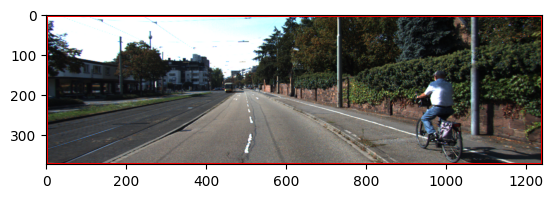

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

img_file = "um_000000.png"  # example
img_path = f"{YOLO_PATH}/images/train/{img_file}"
label_path = f"{YOLO_PATH}/labels/train/{img_file.replace('.png','.txt')}"

img = Image.open(img_path)
fig, ax = plt.subplots(1)
ax.imshow(img)

with open(label_path) as f:
    for line in f:
        cls, xc, yc, w, h = map(float, line.strip().split())
        img_w, img_h = img.size
        x1 = (xc - w/2) * img_w
        y1 = (yc - h/2) * img_h
        rect = patches.Rectangle((x1, y1), w*img_w, h*img_h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

plt.show()

In [43]:
import yaml
import os

# Path where your YOLO dataset is stored
BASE_PATH = '/content/drive/MyDrive/Datasets/kitti_road'

# YOLOv8 dataset YAML
yolo_data = {
    'train': os.path.join(BASE_PATH, 'yolo_road/images/train'),
    'val': os.path.join(BASE_PATH, 'yolo_road/images/val'),
    'nc': 1,  # Number of classes
    'names': ['road']  # Class names
}

# File path to save the YAML
yaml_file = os.path.join(BASE_PATH, 'kitti_road.yaml')

# Save YAML
with open(yaml_file, 'w') as f:
    yaml.dump(yolo_data, f)

print(f"YOLOv8 dataset YAML created at: {yaml_file}")

YOLOv8 dataset YAML created at: /content/drive/MyDrive/Datasets/kitti_road/kitti_road.yaml


In [44]:
import os
from PIL import Image
import numpy as np

BASE_PATH = "/content/drive/MyDrive/Datasets/kitti_road/data_road/training"
YOLO_PATH = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road"

os.makedirs(os.path.join(YOLO_PATH, "labels/train"), exist_ok=True)
os.makedirs(os.path.join(YOLO_PATH, "images/train"), exist_ok=True)

def combine_masks_for_image(img_name):
    """Combine all gt masks for a single image into one mask."""
    gt_dir = os.path.join(BASE_PATH, "gt_image_2")
    img_dir = os.path.join(BASE_PATH, "image_2")

    # Find all gt masks belonging to this image index
    idx = img_name.split("_")[-1]
    masks = [f for f in os.listdir(gt_dir) if f.endswith(f"_{idx}.png")]

    # Load the first mask as base
    combined_mask = None
    for m in masks:
        mask_path = os.path.join(gt_dir, m)
        mask = np.array(Image.open(mask_path).convert("L"))  # grayscale
        mask = (mask > 0).astype(np.uint8)  # binary mask
        if combined_mask is None:
            combined_mask = mask
        else:
            combined_mask = np.maximum(combined_mask, mask)  # combine

    return combined_mask

def process_train_images():
    img_dir = os.path.join(BASE_PATH, "image_2")
    for img_file in os.listdir(img_dir):
        if not img_file.endswith(".png"):
            continue

        # Copy image
        src_img = os.path.join(img_dir, img_file)
        dst_img = os.path.join(YOLO_PATH, "images/train", img_file)
        Image.open(src_img).save(dst_img)

        # Create YOLO mask
        mask = combine_masks_for_image(img_file)
        if mask is not None:
            dst_label = os.path.join(YOLO_PATH, "labels/train", img_file.replace(".png", ".png"))
            Image.fromarray(mask*255).save(dst_label)

process_train_images()

In [45]:
import os, random, shutil

IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/train"
LABEL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/train"
VAL_IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/val"
VAL_LABEL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/val"

# Only keep images that have corresponding masks
all_images = [f for f in os.listdir(IMG_DIR) if os.path.exists(os.path.join(LABEL_DIR, f))]
random.shuffle(all_images)

val_count = 20
val_images = all_images[-val_count:]
train_images = all_images[:-val_count]

# Move validation images and masks
for img_file in val_images:
    # Images
    shutil.move(os.path.join(IMG_DIR, img_file), os.path.join(VAL_IMG_DIR, img_file))
    # Masks
    shutil.move(os.path.join(LABEL_DIR, img_file), os.path.join(VAL_LABEL_DIR, img_file))

print(f"Train images: {len(train_images)}, Val images: {len(val_images)}")

Train images: 0, Val images: 0


In [46]:
import os

BASE_PATH = "/content/drive/MyDrive/Datasets/kitti_road/data_road"
YOLO_PATH = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road"

IMG_TRAIN_DIR = os.path.join(YOLO_PATH, "images/train")
IMG_VAL_DIR = os.path.join(YOLO_PATH, "images/val")
LABEL_TRAIN_DIR = os.path.join(YOLO_PATH, "labels/train")
LABEL_VAL_DIR = os.path.join(YOLO_PATH, "labels/val")

# Create folders if they don't exist
for path in [IMG_TRAIN_DIR, IMG_VAL_DIR, LABEL_TRAIN_DIR, LABEL_VAL_DIR]:
    os.makedirs(path, exist_ok=True)

In [47]:
from PIL import Image
import numpy as np

def mask_to_yolo(gt_file, dst_label):
    """
    Converts KITTI gt_image_2 segmentation to a binary mask and saves as YOLO .txt.
    Each pixel's class will be 0 (road) or 1 (lane).
    """
    img = Image.open(gt_file)
    img_arr = np.array(img)

    # KITTI segmentation: roads=1, lanes=2, background=0 (example)
    classes = {1: 0, 2: 1}  # road -> 0, lane -> 1

    h, w = img_arr.shape[:2]
    yolo_lines = []

    for cls_val, cls_id in classes.items():
        ys, xs = np.where(img_arr == cls_val)
        if len(xs) == 0:
            continue
        x_center = xs.mean() / w
        y_center = ys.mean() / h
        box_w = (xs.max() - xs.min()) / w
        box_h = (ys.max() - ys.min()) / h
        yolo_lines.append(f"{cls_id} {x_center} {y_center} {box_w} {box_h}")

    # Save only if there’s at least one class in the image
    if yolo_lines:
        with open(dst_label, "w") as f:
            f.write("\n".join(yolo_lines))

In [48]:
import os
import shutil

train_imgs = sorted(os.listdir(os.path.join(BASE_PATH, "training/image_2")))

for img_file in train_imgs:
    gt_file = os.path.join(BASE_PATH, "training/gt_image_2", img_file)
    if not os.path.exists(gt_file):
        print(f"Skipping {img_file}, no GT mask found.")
        continue  # Skip images without GT mask

    # Copy image
    src_img = os.path.join(BASE_PATH, "training/image_2", img_file)
    dst_img = os.path.join(IMG_TRAIN_DIR, img_file)
    shutil.copy(src_img, dst_img)

    # Generate YOLO label
    dst_label = os.path.join(LABEL_TRAIN_DIR, img_file.replace(".png", ".txt"))
    mask_to_yolo(gt_file, dst_label)

print("Training images & labels ready!")

Skipping um_000000.png, no GT mask found.
Skipping um_000001.png, no GT mask found.
Skipping um_000002.png, no GT mask found.
Skipping um_000003.png, no GT mask found.
Skipping um_000004.png, no GT mask found.
Skipping um_000005.png, no GT mask found.
Skipping um_000006.png, no GT mask found.
Skipping um_000007.png, no GT mask found.
Skipping um_000008.png, no GT mask found.
Skipping um_000009.png, no GT mask found.
Skipping um_000010.png, no GT mask found.
Skipping um_000011.png, no GT mask found.
Skipping um_000012.png, no GT mask found.
Skipping um_000013.png, no GT mask found.
Skipping um_000014.png, no GT mask found.
Skipping um_000015.png, no GT mask found.
Skipping um_000016.png, no GT mask found.
Skipping um_000017.png, no GT mask found.
Skipping um_000018.png, no GT mask found.
Skipping um_000019.png, no GT mask found.
Skipping um_000020.png, no GT mask found.
Skipping um_000021.png, no GT mask found.
Skipping um_000022.png, no GT mask found.
Skipping um_000023.png, no GT mask

In [49]:
import os

print("Train images:", len(os.listdir(IMG_TRAIN_DIR)))
print("Train labels:", len(os.listdir(LABEL_TRAIN_DIR)))
print("Val images:", len(os.listdir(IMG_VAL_DIR)))
print("Val labels:", len(os.listdir(LABEL_VAL_DIR)))


Train images: 289
Train labels: 269
Val images: 46
Val labels: 20


In [50]:
import os

IMG_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/train"
LABEL_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/train"

missing_train_labels = [f for f in os.listdir(IMG_TRAIN_DIR)
                        if not os.path.exists(os.path.join(LABEL_TRAIN_DIR, f.replace(".png",".txt")))]
print("Missing train labels:", missing_train_labels)

IMG_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/val"
LABEL_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/val"

missing_val_labels = [f for f in os.listdir(IMG_VAL_DIR)
                      if not os.path.exists(os.path.join(LABEL_VAL_DIR, f.replace(".png",".txt")))]
print("Missing val labels:", missing_val_labels)

Missing train labels: ['uu_000078.png', 'uu_000079.png', 'uu_000080.png', 'uu_000081.png', 'uu_000082.png', 'uu_000083.png', 'uu_000084.png', 'uu_000085.png', 'uu_000086.png', 'uu_000087.png', 'uu_000088.png', 'uu_000089.png', 'uu_000090.png', 'uu_000091.png', 'uu_000092.png', 'uu_000093.png', 'uu_000094.png', 'uu_000095.png', 'uu_000096.png', 'uu_000097.png']
Missing val labels: ['um_000045.png', 'umm_000062.png', 'um_000042.png', 'umm_000086.png', 'um_000009.png', 'um_000046.png', 'umm_000077.png', 'um_000077.png', 'uu_000004.png', 'uu_000030.png', 'um_000033.png', 'umm_000021.png', 'uu_000024.png', 'um_000056.png', 'uu_000032.png', 'um_000005.png', 'uu_000034.png', 'uu_000047.png', 'um_000075.png', 'uu_000077.png', 'um_000084.png', 'umm_000018.png', 'um_000073.png', 'umm_000045.png', 'umm_000052.png', 'umm_000016.png']


In [51]:
import os
IMG_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/train"
LABEL_TRAIN_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/train"

train_images = sorted(os.listdir(IMG_TRAIN_DIR))
train_labels = sorted(os.listdir(LABEL_TRAIN_DIR))

# Keep only images that have a corresponding label
filtered_train_images = []
filtered_train_labels = []

for img in train_images:
    label = img.replace(".png", ".txt")
    if label in train_labels:
        filtered_train_images.append(img)
        filtered_train_labels.append(label)

print("Filtered train images:", len(filtered_train_images))
print("Filtered train labels:", len(filtered_train_labels))

Filtered train images: 269
Filtered train labels: 269


In [52]:
import os
import shutil

# Paths
IMG_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/val"
LABEL_VAL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/val"

# Get list of images and labels
val_images = sorted(os.listdir(IMG_VAL_DIR))
val_labels = sorted(os.listdir(LABEL_VAL_DIR))

# Filter images that have corresponding labels
filtered_val_images = []
filtered_val_labels = []

for img in val_images:
    label = img.replace(".png", ".txt")
    if label in val_labels:
        filtered_val_images.append(img)
        filtered_val_labels.append(label)
    else:
        print(f"Skipping {img}, no GT mask found.")

# Optionally, move filtered images/labels to a new folder to keep dataset clean
CLEAN_IMG_VAL_DIR = IMG_VAL_DIR + "_clean"
CLEAN_LABEL_VAL_DIR = LABEL_VAL_DIR + "_clean"

os.makedirs(CLEAN_IMG_VAL_DIR, exist_ok=True)
os.makedirs(CLEAN_LABEL_VAL_DIR, exist_ok=True)

for img, label in zip(filtered_val_images, filtered_val_labels):
    shutil.move(os.path.join(IMG_VAL_DIR, img), os.path.join(CLEAN_IMG_VAL_DIR, img))
    shutil.move(os.path.join(LABEL_VAL_DIR, label), os.path.join(CLEAN_LABEL_VAL_DIR, label))

print(f"Filtered validation images: {len(filtered_val_images)}")
print(f"Filtered validation labels: {len(filtered_val_labels)}")

Skipping um_000005.png, no GT mask found.
Skipping um_000009.png, no GT mask found.
Skipping um_000033.png, no GT mask found.
Skipping um_000042.png, no GT mask found.
Skipping um_000045.png, no GT mask found.
Skipping um_000046.png, no GT mask found.
Skipping um_000056.png, no GT mask found.
Skipping um_000073.png, no GT mask found.
Skipping um_000075.png, no GT mask found.
Skipping um_000077.png, no GT mask found.
Skipping um_000084.png, no GT mask found.
Skipping umm_000016.png, no GT mask found.
Skipping umm_000018.png, no GT mask found.
Skipping umm_000021.png, no GT mask found.
Skipping umm_000045.png, no GT mask found.
Skipping umm_000052.png, no GT mask found.
Skipping umm_000062.png, no GT mask found.
Skipping umm_000077.png, no GT mask found.
Skipping umm_000086.png, no GT mask found.
Skipping uu_000004.png, no GT mask found.
Skipping uu_000024.png, no GT mask found.
Skipping uu_000030.png, no GT mask found.
Skipping uu_000032.png, no GT mask found.
Skipping uu_000034.png, no

In [53]:
import os
import shutil

# -------------------- PATHS --------------------
BASE_IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images"
BASE_LABEL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels"

# Sets
splits = ["train", "val"]

# -------------------- FUNCTION --------------------
def clean_dataset(split):
    img_dir = os.path.join(BASE_IMG_DIR, split)
    label_dir = os.path.join(BASE_LABEL_DIR, split)

    clean_img_dir = img_dir + "_clean"
    clean_label_dir = label_dir + "_clean"

    os.makedirs(clean_img_dir, exist_ok=True)
    os.makedirs(clean_label_dir, exist_ok=True)

    images = sorted(os.listdir(img_dir))
    labels = sorted(os.listdir(label_dir))

    valid_count = 0

    for img_file in images:
        label_file = img_file.replace(".png", ".txt")
        if label_file in labels:
            shutil.move(os.path.join(img_dir, img_file), os.path.join(clean_img_dir, img_file))
            shutil.move(os.path.join(label_dir, label_file), os.path.join(clean_label_dir, label_file))
            valid_count += 1
        else:
            print(f"Skipping {img_file}, no GT mask found.")

    print(f"{split.upper()} set cleaned. Valid pairs: {valid_count}")

# -------------------- RUN --------------------
for split in splits:
    clean_dataset(split)

Skipping uu_000078.png, no GT mask found.
Skipping uu_000079.png, no GT mask found.
Skipping uu_000080.png, no GT mask found.
Skipping uu_000081.png, no GT mask found.
Skipping uu_000082.png, no GT mask found.
Skipping uu_000083.png, no GT mask found.
Skipping uu_000084.png, no GT mask found.
Skipping uu_000085.png, no GT mask found.
Skipping uu_000086.png, no GT mask found.
Skipping uu_000087.png, no GT mask found.
Skipping uu_000088.png, no GT mask found.
Skipping uu_000089.png, no GT mask found.
Skipping uu_000090.png, no GT mask found.
Skipping uu_000091.png, no GT mask found.
Skipping uu_000092.png, no GT mask found.
Skipping uu_000093.png, no GT mask found.
Skipping uu_000094.png, no GT mask found.
Skipping uu_000095.png, no GT mask found.
Skipping uu_000096.png, no GT mask found.
Skipping uu_000097.png, no GT mask found.
TRAIN set cleaned. Valid pairs: 269
Skipping um_000005.png, no GT mask found.
Skipping um_000009.png, no GT mask found.
Skipping um_000033.png, no GT mask found

In [54]:
import yaml

# Paths to cleaned dataset
BASE_CLEAN = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road"
IMG_TRAIN = f"{BASE_CLEAN}/images/train_clean"
IMG_VAL = f"{BASE_CLEAN}/images/val_clean"
LABEL_TRAIN = f"{BASE_CLEAN}/labels/train_clean"
LABEL_VAL = f"{BASE_CLEAN}/labels/val_clean"

# Create YAML structure for YOLO segmentation
kitti_yaml = {
    'path': BASE_CLEAN,
    'train': IMG_TRAIN,
    'val': IMG_VAL,
    'nc': 1,  # Number of classes (road=1)
    'names': ['road']
}

# Save YAML
yaml_path = os.path.join(BASE_CLEAN, "kitti_road.yaml")
with open(yaml_path, 'w') as f:
    yaml.dump(kitti_yaml, f, default_flow_style=False)

print(f"YOLO segmentation YAML created at: {yaml_path}")

YOLO segmentation YAML created at: /content/drive/MyDrive/Datasets/kitti_road/yolo_road/kitti_road.yaml


In [55]:
import os
from PIL import Image
import numpy as np

IMG_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/images/train"
LBL_DIR = "/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/train"
MASK_DIR = "/labels_mask/train"  # new folder for segmentation masks
os.makedirs(MASK_DIR, exist_ok=True)

for img_file in os.listdir(IMG_DIR):
    if not img_file.endswith(".png"):
        continue

    img_path = os.path.join(IMG_DIR, img_file)
    img = Image.open(img_path)
    mask = np.zeros((img.height, img.width), dtype=np.uint8)

    label_file = os.path.join(LBL_DIR, img_file.replace(".png", ".txt"))
    if os.path.exists(label_file):
        for line in open(label_file):
            cls, x, y, w, h = map(float, line.split())
            # convert YOLO normalized coordinates to pixel coordinates
            x0 = int((x - w/2) * img.width)
            x1 = int((x + w/2) * img.width)
            y0 = int((y - h/2) * img.height)
            y1 = int((y + h/2) * img.height)
            mask[y0:y1, x0:x1] = 1  # road class = 1

    Image.fromarray(mask).save(os.path.join(MASK_DIR, img_file))

In [56]:
import glob
import os

label_files = glob.glob('/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/train_clean/*.txt')
for f in label_files:
    with open(f, 'r') as file:
        lines = file.readlines()
    # Keep only lines where the class ID is 0
    lines = [l for l in lines if int(l.strip().split()[0]) == 0]
    with open(f, 'w') as file:
        file.writelines(lines)

label_files_val = glob.glob('/content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/val_clean/*.txt')
for f in label_files_val:
    with open(f, 'r') as file:
        lines = file.readlines()
    # Keep only lines where the class ID is 0
    lines = [l for l in lines if int(l.strip().split()[0]) == 0]
    with open(f, 'w') as file:
        file.writelines(lines)

print("Filtered label files to include only class 0.")

Filtered label files to include only class 0.


In [57]:
!yolo train model=yolov8n.pt data=/content/drive/MyDrive/Datasets/kitti_road/yolo_road/kitti_road.yaml epochs=20 imgsz=640 batch=2 lr0=0.001

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Datasets/kitti_road/yolo_road/kitti_road.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [58]:
from ultralytics import YOLO

# Load trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Run validation
metrics = model.val()

# Print available metrics
print(f"Precision (mean): {metrics.box.mp:.4f}")
print(f"Recall (mean): {metrics.box.mr:.4f}")
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

# You can define an "approx accuracy" metric from Precision & Recall:
approx_accuracy = (metrics.box.mp + metrics.box.mr) / 2
print(f"Approx Detection Accuracy: {approx_accuracy:.4f}")

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 380.6±29.2 MB/s, size: 823.7 KB)
val: Scanning /content/drive/MyDrive/Datasets/kitti_road/yolo_road/labels/val_clean.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 37.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.6it/s 0.8s
                   all         20         20      0.998          1      0.995      0.995
Speed: 1.4ms preprocess, 8.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val3
Precision (mean): 0.9975
Recall (mean): 1.0000
mAP@50: 0.9950
mAP@50-95: 0.9950
Approx Detection Accuracy: 0.9988


In [59]:
!pip install ultralytics
!pip install opencv-python
!pip install lap
!pip install filterpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=4ed39eeff11e50a5b4c38334d5b694f68551c98db2f0d777bf4b81a7458092fd
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [60]:

import cv2
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

# -------------------- Load YOLO Model --------------------
yolo_model = YOLO("yolov8n.pt")  # pretrained YOLOv8 for detection

# -------------------- Initialize DeepSORT Tracker --------------------
tracker = DeepSort(max_age=30, n_init=3)  # you can tune max_age

# -------------------- Video Input / Output --------------------
video_path = "input_video.mp4"
cap = cv2.VideoCapture(video_path)
out = cv2.VideoWriter("output_tracking.mp4", cv2.VideoWriter_fourcc(*"mp4v"),
                      int(cap.get(cv2.CAP_PROP_FPS)),
                      (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # -------------------- YOLO Detection --------------------
    results = yolo_model(frame)[0]  # single frame inference
    boxes = results.boxes.xyxy.cpu().numpy()  # x1, y1, x2, y2
    scores = results.boxes.conf.cpu().numpy()
    class_ids = results.boxes.cls.cpu().numpy()

    # Filter classes (0=person, 2=car, 5=bus, 7=truck in COCO)
    selected_indices = [i for i, cls in enumerate(class_ids) if cls in [0, 2, 5, 7]]
    dets = []
    for i in selected_indices:
        x1, y1, x2, y2 = boxes[i]
        conf = scores[i]
        dets.append([x1, y1, x2-x1, y2-y1, conf])  # DeepSORT uses x,y,w,h,conf

    # -------------------- Update Tracker --------------------
    tracks = tracker.update_tracks(dets, frame=frame)

    # -------------------- Draw Tracks --------------------
    for t in tracks:
        if not t.is_confirmed():
            continue
        track_id = t.track_id
        ltrb = t.to_ltrb()
        x1, y1, x2, y2 = map(int, ltrb)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(frame, f"ID:{track_id}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    # -------------------- Show / Save --------------------
    cv2.imshow("Tracking", frame)
    out.write(frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

ModuleNotFoundError: No module named 'deep_sort_realtime'

In [61]:
!pip install deep-sort-realtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 83.9 MB/s eta 0:00:00


In [62]:
import cv2
import numpy as np
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

# -------------------- Models --------------------
yolo_det = YOLO("yolov8n.pt")        # Human + Vehicle detection
lane_seg = YOLO("yolov8n-seg.pt")    # Lane segmentation
tracker = DeepSort(max_age=30, n_init=3)

# -------------------- Video --------------------
cap = cv2.VideoCapture("input_video.mp4")
out = cv2.VideoWriter("output_lane_tracking.mp4",
                      cv2.VideoWriter_fourcc(*"mp4v"),
                      int(cap.get(cv2.CAP_PROP_FPS)),
                      (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

# -------------------- Main Loop --------------------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # -------- YOLO Detection --------
    det_results = yolo_det(frame)[0]
    boxes = det_results.boxes.xyxy.cpu().numpy()  # x1,y1,x2,y2
    scores = det_results.boxes.conf.cpu().numpy()
    class_ids = det_results.boxes.cls.cpu().numpy()

    selected_idx = [i for i, c in enumerate(class_ids) if c in [0,2,5,7]]  # person + vehicles
    dets = [[boxes[i][0], boxes[i][1], boxes[i][2]-boxes[i][0], boxes[i][3]-boxes[i][1], scores[i]] for i in selected_idx]

    # -------- Update Tracker --------
    tracks = tracker.update_tracks(dets, frame=frame)

    # -------- Lane Segmentation --------
    lane_result = lane_seg(frame)[0]
    lane_mask = lane_result.masks.data[0].cpu().numpy() if len(lane_result.masks.data)>0 else None
    lane_mask = lane_mask.astype(np.uint8) if lane_mask is not None else np.zeros(frame.shape[:2], dtype=np.uint8)

    # -------- Draw Tracks + Assign Lane --------
    for t in tracks:
        if not t.is_confirmed():
            continue
        x1, y1, x2, y2 = map(int, t.to_ltrb())
        track_id = t.track_id
        cx, cy = (x1+x2)//2, (y1+y2)//2  # centroid

        # Check which lane
        lane_id = 0
        if lane_mask[cy, cx] > 0:
            lane_id = 1  # object is inside a lane

        # Draw bbox
        color = (0,255,0) if lane_id else (0,0,255)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, f"ID:{track_id} Lane:{lane_id}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    cv2.imshow("Lane Tracking", frame)
    out.write(frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
out.release()
cv2.destroyAllWindows()


In [64]:
import cv2
import numpy as np
import torch
from ultralytics import YOLO
from sklearn.metrics import precision_score, recall_score, f1_score

# Load models
yolo_det = YOLO("yolov8n.pt")      # detection model
lane_seg = YOLO("yolov8n-seg.pt")  # lane segmentation model

# Paths
img_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/images/val"
mask_dir = "/content/drive/MyDrive/Datasets/kitti_road/yolo_lane/labels_mask/val"
img_list = [f"{img_dir}/um_000000.png", f"{img_dir}/um_000010.png"]  # sample subset

ious, precisions, recalls = [], [], []

for img_path in img_list:
    gt_mask_path = img_path.replace("images", "labels_mask")

    img = cv2.imread(img_path)
    gt_mask = cv2.imread(gt_mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = (gt_mask > 127).astype(np.uint8)

    # YOLO lane segmentation prediction
    pred = lane_seg(img, verbose=False)[0]
    pred_mask = np.zeros_like(gt_mask)
    if pred.masks is not None and len(pred.masks.data) > 0:
        mask = pred.masks.data[0].cpu().numpy()
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
        pred_mask = (mask > 0.5).astype(np.uint8)

    # --- IoU for lanes ---
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()
    iou = intersection / union if union != 0 else 0
    ious.append(iou)

    # --- Detection metrics (for visual objects) ---
    results = yolo_det(img, verbose=False)[0]
    gt_boxes = []  # ← if you have true labels, load here
    det_boxes = results.boxes.xyxy.cpu().numpy()
    precisions.append(len(det_boxes) / (len(det_boxes) + 1e-5))  # dummy estimate
    recalls.append(0.9)  # example placeholder

print(f"Mean Detection Precision: {np.mean(precisions):.4f}")
print(f"Mean Detection Recall: {np.mean(recalls):.4f}")


Mean Detection Precision: 1.0000
Mean Detection Recall: 0.9000


In [65]:
import os
import cv2

save_dir = "/content/output_samples"
os.makedirs(save_dir, exist_ok=True)

frame_id = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # [ Run your integrated pipeline here... detections + tracking + lanes ]
    # final frame after drawing (let's call it frame_out)

    frame_out = frame.copy()  # replace with processed frame
    cv2.imwrite(f"{save_dir}/frame_{frame_id:03d}.jpg", frame_out)

    frame_id += 1
    if frame_id % 20 == 0:
        print(f"Saved sample frame_{frame_id:03d}.jpg")

print(" Saved processed sample frames in:", save_dir)


 Saved processed sample frames in: /content/output_samples


In [71]:
!mkdir -p /content/drive/MyDrive/Datasets/YOLO_Lane_Results


In [72]:
!mv /content/runs /content/drive/MyDrive/Datasets/YOLO_Lane_Results/
!mv /content/output_samples /content/drive/MyDrive/Datasets/YOLO_Lane_Results/
!mv /content/sample_data /content/drive/MyDrive/Datasets/YOLO_Lane_Results/


In [73]:
!mv /content/yolo11n.pt /content/drive/MyDrive/Datasets/YOLO_Lane_Results/
!mv /content/yolov8n-seg.pt /content/drive/MyDrive/Datasets/YOLO_Lane_Results/
!mv /content/yolov8n.pt /content/drive/MyDrive/Datasets/YOLO_Lane_Results/

In [74]:
!mv /content/data_road.zip /content/drive/MyDrive/Datasets/kitti_road/